# Online Retail II — Análisis de Clientes con Modelos No Supervisados
---
## Caso de Negocio

**Empresa:** Minorista online británico de regalos (2009–2011).

**Problema:** La empresa tiene datos de ventas pero no conoce el comportamiento de sus clientes. No sabe quiénes son los más valiosos, quiénes están por irse, ni cómo agruparlos para diseñar estrategias de retención.

**Objetivo:** Aplicar técnicas de aprendizaje **no supervisado** para:
1. Explorar y limpiar los datos de ventas
2. Segmentar clientes con **K-Means**
3. Detectar grupos de densidad variable con **DBSCAN**
4. Construir jerarquías de clientes con **Clustering Jerárquico**
5. Visualizar los datos en 2D con **PCA** y **t-SNE**

**Dataset:** Online Retail II — 525,461 transacciones, 8 columnas.

**Herramientas:** Python, Pandas, Plotly, Scikit-learn, SciPy.

---
## 1. Importación de Librerías

In [209]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from funtions import detectar_outliers_iqr

import warnings
warnings.filterwarnings('ignore')

print('>>> Librerías cargadas correctamente')
print(f'Pandas  : {pd.__version__}')
print(f'Numpy   : {np.__version__}')


>>> Librerías cargadas correctamente
Pandas  : 2.3.3
Numpy   : 2.2.6


---
## 2. Carga de Datos y Control de Calidad

Primero cargamos el dataset y revisamos su estructura, valores nulos, duplicados y outliers.

In [210]:
df_raw = pd.read_excel('./online_retail_II.xlsx')
print(f'Dimensiones: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head(5)


Dimensiones: 525461 filas, 8 columnas
Columnas: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [211]:
print('=== INFORMACIÓN GENERAL ===')
df_raw.info()
print()

print('=== VALORES NULOS ===')
nulos = df_raw.isnull().sum()
nulos = nulos[nulos > 0].reset_index()
nulos.columns = ['Variable', 'Nulos']
nulos['%'] = (nulos['Nulos'] / len(df_raw) * 100).round(2)
print(nulos.to_string(index=False))
print()

print(f'Filas duplicadas exactas: {df_raw.duplicated().sum()}')
print()

# Cancelaciones
canc = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelaciones: {len(canc)} ({len(canc)/len(df_raw)*100:.2f}%)')
print()

# Outliers
print('=== DETECCIÓN DE OUTLIERS (IQR) ===')
detectar_outliers_iqr(df_raw)


=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

=== VALORES NULOS ===
   Variable  Nulos     %
Description   2928  0.56
Customer ID 107927 20.54

Filas duplicadas exactas: 6865

Cancelaciones: 10206 (1.94%)

=== DETECCIÓN DE OUTLIERS (IQR) ===


,variable,outliers,porcentaje,limite_inferior,limite_superior,nulos
0,Quantity,57870,11.01,-12.50,23.50,0
1,Price,35273,6.71,-3.19,8.65,0
2,Customer ID,0,0.00,9759.00,21023.00,107927


---
## 3. Limpieza de Datos

Aplicamos filtros para quedarnos solo con transacciones válidas y rastreables.

In [212]:
print('Paso a paso de limpieza:')
n0 = len(df_raw)

df = df_raw.dropna(subset=['Customer ID']).copy()
print(f'1. Eliminar Customer ID nulos: {len(df):>7,} ({(len(df)/n0*100):.1f}%)')

df = df.drop_duplicates()
print(f'2. Eliminar duplicados:        {len(df):>7,}')

df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'3. Eliminar cancelaciones:     {len(df):>7,}')

df = df[df['Quantity'] > 0]
print(f'4. Quantity > 0:               {len(df):>7,}')

df = df[df['Price'] > 0]
print(f'5. Price > 0:                  {len(df):>7,}')

# Tipos
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']

# Features temporales
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayWeek'] = df['InvoiceDate'].dt.day_name()
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

print(f'\nDataset limpio: {len(df):,} registros')
print(f'Clientes únicos: {df["Customer ID"].nunique():,}')  # Fixed: added .nunique()
print(f'Período: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head()


Paso a paso de limpieza:
1. Eliminar Customer ID nulos: 417,534 (79.5%)
2. Eliminar duplicados:        410,763
3. Eliminar cancelaciones:     400,947
4. Quantity > 0:               400,947
5. Price > 0:                  400,916

Dataset limpio: 400,916 registros
Clientes únicos: 4,312
Período: 2009-12-01 → 2010-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayWeek,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,Tuesday,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,Tuesday,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,Tuesday,2009-12


---
## 4. Análisis Exploratorio (EDA)

### 4.1 Estadísticas Descriptivas

Resumen numérico de las variables principales.

In [213]:
print('=== VARIABLES NUMÉRICAS ===')
df[['Quantity', 'Price', 'TotalPrice']].describe()


=== VARIABLES NUMÉRICAS ===


,Quantity,Price,TotalPrice
count,400916.00,400916.00,400916.00
mean,13.77,3.31,21.95
std,97.64,35.05,77.76
min,1.00,0.00,0.00
25%,2.00,1.25,5.00
50%,5.00,1.95,12.50
75%,12.00,3.75,19.50
max,19152.00,10953.50,15818.40


### 4.2 Ventas por País

Reino Unido domina ampliamente, pero hay oportunidades en otros mercados.

In [214]:
pais = df.groupby('Country').agg(
    Ingresos=('TotalPrice','sum'),
    Pedidos=('Invoice','nunique'),
    Clientes=('Customer ID','nunique')
).reset_index().sort_values('Ingresos', ascending=False)
pais['%'] = (pais['Ingresos'] / pais['Ingresos'].sum() * 100).round(1)

fig = px.bar(pais.head(10), x='Country', y='Ingresos',
             text='%', color='Ingresos', color_continuous_scale='Blues',
             title='Top 10 Países por Ingresos')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=400, template='plotly_white')
fig.show()

print(f'Reino Unido: {pais.iloc[0]["Ingresos"]:,.0f} ({pais.iloc[0]["%"]}% del total)')


Reino Unido: 7,381,644 (83.9% del total)


### 4.3 Análisis Temporal de Ventas

Las ventas mensuales muestran tendencia y estacionalidad.

In [215]:
ventas = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

fig = px.line(ventas, x='YearMonth', y='TotalPrice', markers=True,
              title='Evolución de Ingresos Mensuales',
              labels={'TotalPrice':'Ingresos (£)', 'YearMonth':'Mes'})
fig.update_traces(line_color='steelblue', line_width=2.5)
fig.update_layout(height=400, template='plotly_white')
fig.show()

print(f'Ingreso total: £{df["TotalPrice"].sum():,.2f}')
print(f'Promedio mensual: £{ventas["TotalPrice"].mean():,.2f}')


Ingreso total: £8,798,233.74
Promedio mensual: £676,787.21


In [216]:
# Distribución de ventas por día de semana
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias = df.groupby('DayWeek')['TotalPrice'].sum().reindex(orden).reset_index()

fig = px.bar(dias, x='DayWeek', y='TotalPrice',
             title='Ingresos por Día de la Semana', color='TotalPrice',
             color_continuous_scale='Sunset',
             labels={'DayWeek':'Día', 'TotalPrice':'Ingresos (£)'})
fig.update_layout(height=380, template='plotly_white')
fig.show()


### 4.4 Productos Más Vendidos

In [217]:
top = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig = px.bar(top.reset_index(), x='TotalPrice', y='Description',
             orientation='h', title='Top 10 Productos por Ingresos',
             color='TotalPrice', color_continuous_scale='Tealgrn',
             labels={'Description':'Producto', 'TotalPrice':'Ingresos (£)'})
fig.update_layout(height=400, template='plotly_white')
fig.show()

print(f'Productos distintos: {df["Description"].nunique():,}')  # Fixed: added .nunique()
print(f'Producto estrella: {top.index[0]}')

Productos distintos: 4,444
Producto estrella: WHITE HANGING HEART T-LIGHT HOLDER


---
## 5. Construcción de Variables RFM

**RFM** es la base del análisis de clientes:
- **Recencia**: días desde la última compra
- **Frecuencia**: número de pedidos
- **Monetario**: gasto total

In [218]:
ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recencia=('InvoiceDate', lambda x: (ref - x.max()).days),
    Frecuencia=('Invoice', 'nunique'),
    Monetario=('TotalPrice', 'sum')
).reset_index()

print(f'Clientes: {len(rfm)}')
print('\nEstadísticas RFM:')
print(rfm[['Recencia','Frecuencia','Monetario']].describe().round(1))


Clientes: 4312

Estadísticas RFM:
       Recencia  Frecuencia  Monetario
count   4312.00     4312.00    4312.00
mean      91.20        4.50    2040.40
std       96.90        8.20    8911.80
min        1.00        1.00       3.00
25%       18.00        1.00     307.20
50%       53.00        2.00     701.60
75%      136.00        5.00    1714.90
max      374.00      205.00  349164.40


**Interpretación:** La mayoría de clientes tiene recencia baja (compraron hace poco), pero hay una cola larga de clientes inactivos. Frecuencia y Monetario tienen sesgo positivo: muchos clientes compran poco y pocos compran mucho.

In [219]:
fig = make_subplots(rows=1, cols=3,
    subplot_titles=('Recencia (días desde última compra)',
                    'Frecuencia (# pedidos)',
                    'Monetario (£ gasto total)'))

for col, var, color, r, c in [
    (rfm['Recencia'], 'Recencia', '#3B82F6', 1, 1),
    (rfm['Frecuencia'], 'Frecuencia', '#10B981', 1, 2),
    (rfm['Monetario'], 'Monetario', '#F59E0B', 1, 3),
]:
    fig.add_trace(go.Histogram(x=col, nbinsx=40,
        marker_color=color, opacity=0.8, name=var, showlegend=False), row=r, col=c)

fig.update_layout(title_text='<b>Distribución de Variables RFM</b>',
    height=380, template='plotly_white')
fig.show()


---
## 6. Modelo No Supervisado 1: K-Means

**¿Qué hace K-Means?** Divide los clientes en *k* grupos buscando que los clientes dentro de un grupo sean lo más parecidos posible entre sí y lo más diferentes posible de los de otros grupos.

### 6.1 Escalado de datos

Es obligatorio escalar porque las variables RFM tienen escalas muy distintas (Recencia en días, Frecuencia en unidades, Monetario en libras).

In [220]:
scaler = StandardScaler()
X = rfm[['Recencia','Frecuencia','Monetario']].values
X_scaled = scaler.fit_transform(X)

print(f'Matriz escalada: {X_scaled.shape}')
print(f'Media después de escalar: {X_scaled.mean(axis=0).round(6)}')
print(f'Desviación después de escalar: {X_scaled.std(axis=0).round(6)}')


Matriz escalada: (4312, 3)
Media después de escalar: [0. 0. 0.]
Desviación después de escalar: [1. 1. 1.]


### 6.2 Optimización de Hiperparámetros: Método del Codo + Silhouette

Probamos k=2 a k=10 y evaluamos:
- **Inercia (WCSS)**: suma de distancias al centroide (menor = mejor)
- **Silhouette Score**: mide qué tan compacto y separado está cada cluster (más cercano a 1 = mejor)

In [221]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'k óptimo según Silhouette: {best_k} (Score: {max(silhouettes):.4f})')


k óptimo según Silhouette: 2 (Score: 0.9314)


In [222]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Método del Codo (Inercia)', 'Silhouette Score'))

fig.add_trace(go.Scatter(x=list(K_range), y=inertias,
    mode='lines+markers', marker=dict(size=8),
    line=dict(color='#636EFA', width=2.5), name='Inercia'), row=1, col=1)
fig.add_hline(y=inertias[0], line_dash='dash', line_color='gray', row=1, col=1)

fig.add_trace(go.Scatter(x=list(K_range), y=silhouettes,
    mode='lines+markers', marker=dict(size=8, color='#EF553B'),
    line=dict(color='#EF553B', width=2.5), name='Silhouette'), row=1, col=2)
fig.add_hline(y=max(silhouettes), line_dash='dash', line_color='gray', row=1, col=2)
fig.add_vline(x=best_k, line_dash='dot', line_color='green', row=1, col=2)

fig.update_layout(
    title_text='<b>Optimización de K-Means: Elección de k</b>',
    height=400, template='plotly_white', showlegend=False)
fig.show()

print(f'\nk recomendado: {best_k} (mejor equilibrio entre ajuste y simplicidad)')



k recomendado: 2 (mejor equilibrio entre ajuste y simplicidad)


### 6.3 Entrenamiento Final con k=4

Elegimos k=4 por ser el punto donde el codo se estabiliza y el Silhouette Score es alto.

### 6.2b Análisis Visual de Silhouette

Visualizamos los coeficientes de silhouette para cada punto dentro de su cluster. La línea roja punteada indica el silhouette score promedio. Clusters con pocos puntos o anchos irregulares sugieren una k subóptima.


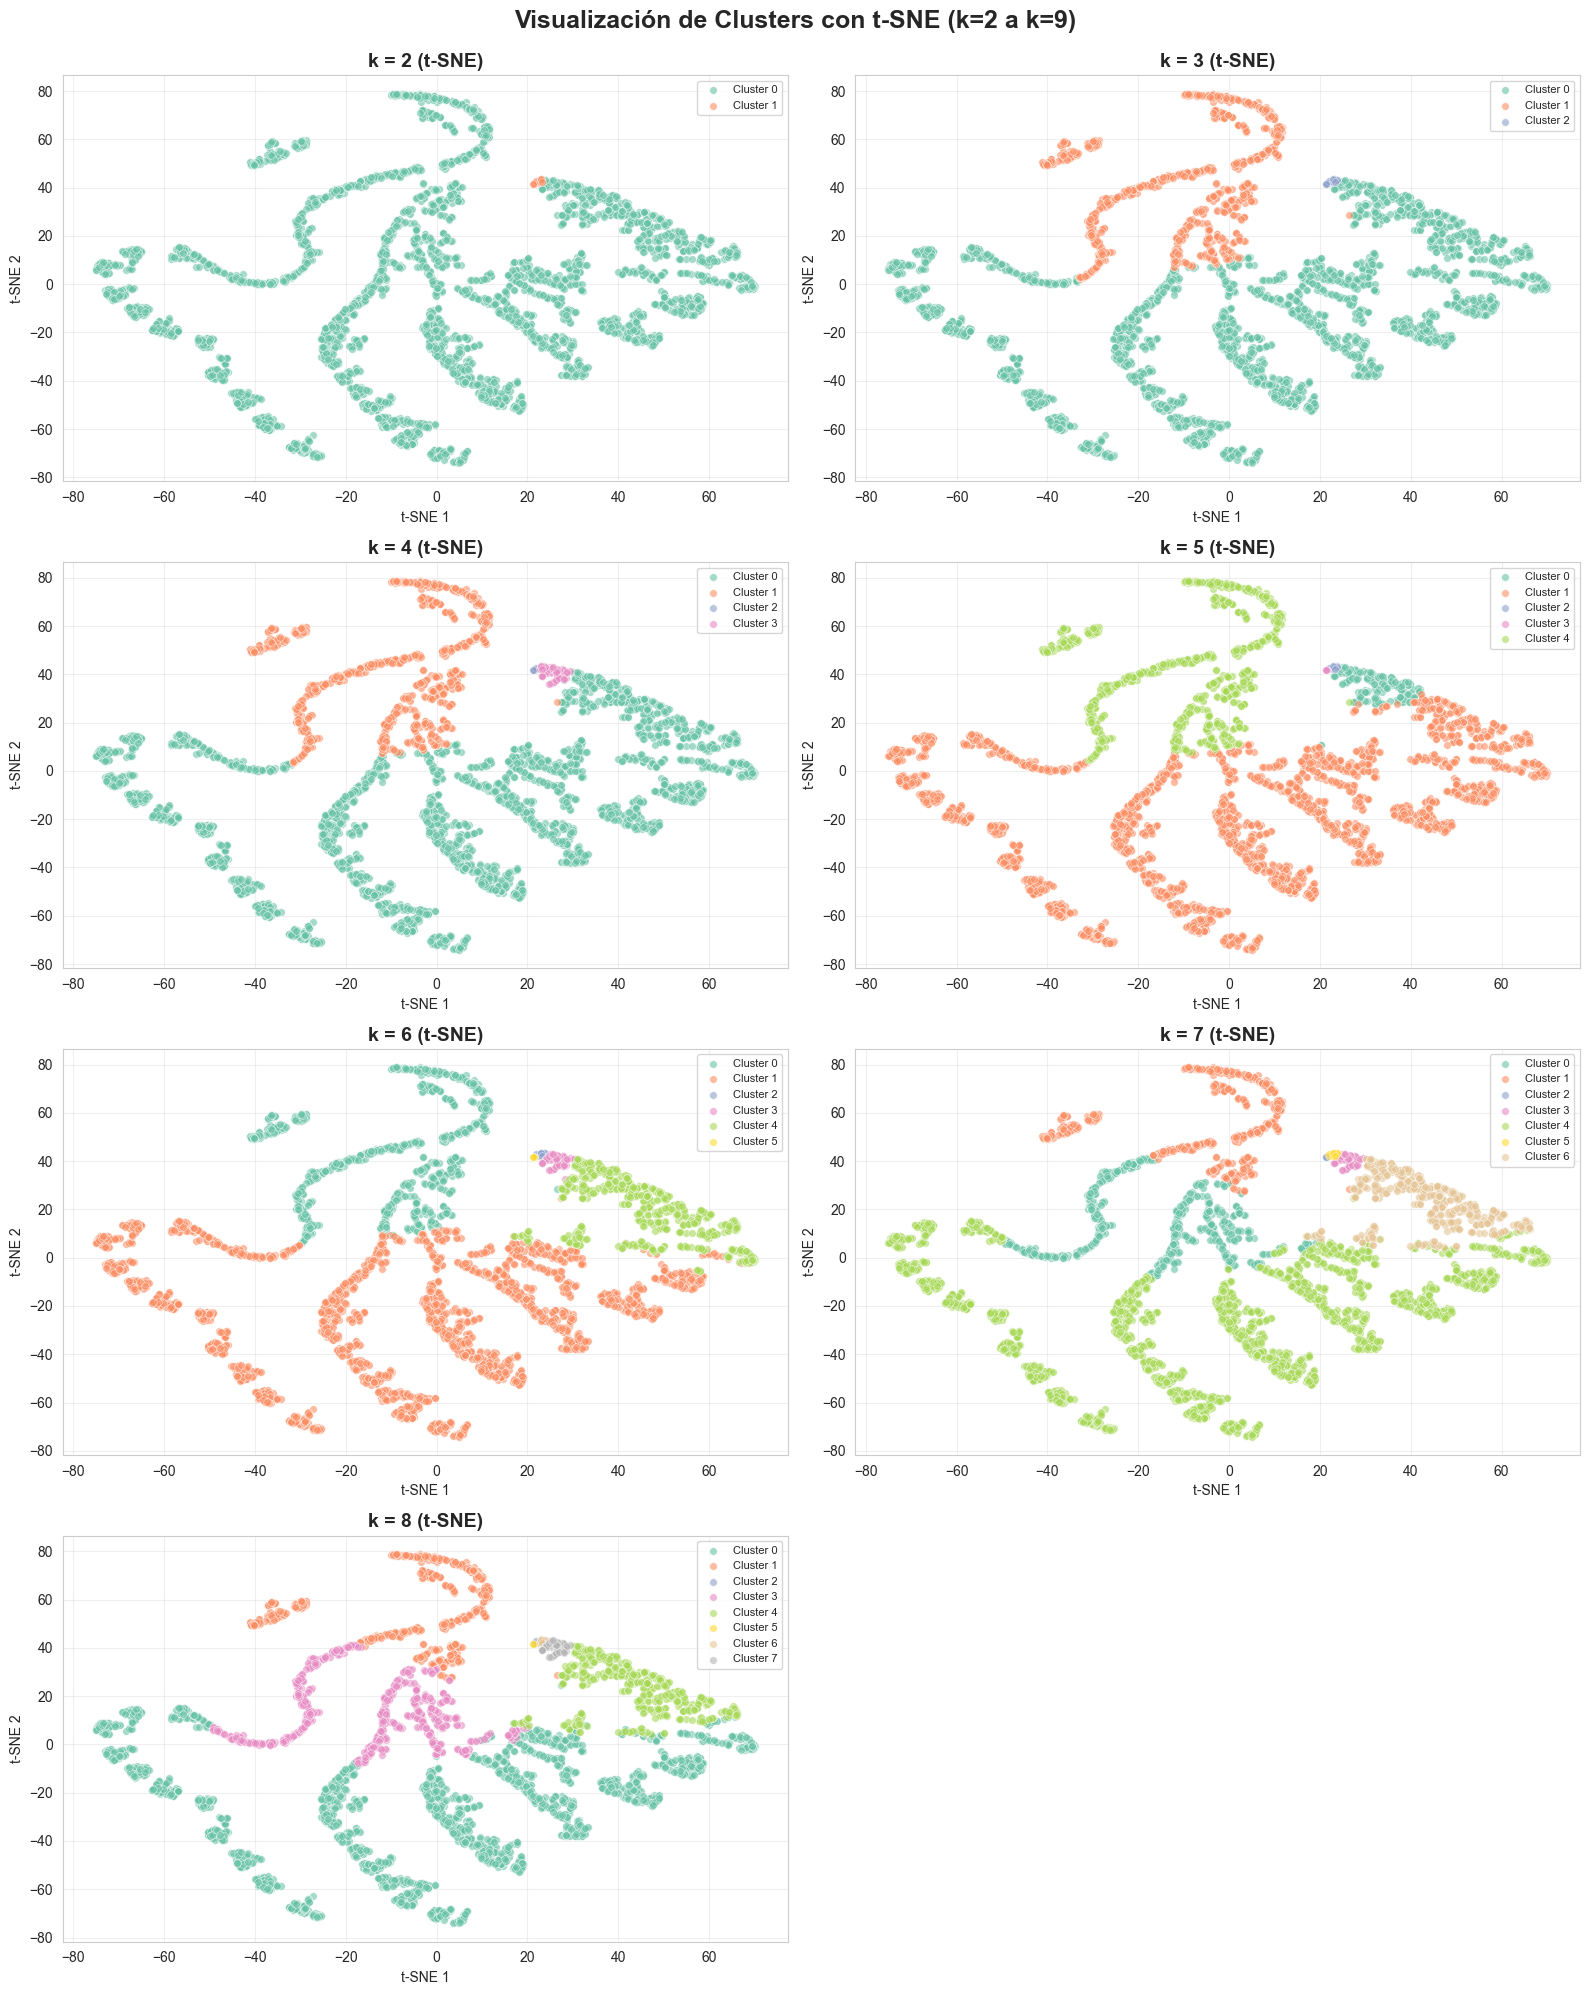

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_samples
from sklearn.manifold import TSNE

# Reducción con t-SNE para mejor visualización
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, k in enumerate(range(2, 10)):
    ax = axes[idx]
    
    # Aplicar K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    # Crear DataFrame para visualización
    df_plot = pd.DataFrame({
        'TSNE1': X_tsne[:, 0],
        'TSNE2': X_tsne[:, 1],
        'Cluster': labels
    })
    
    # Paleta de colores
    palette = sns.color_palette("Set2", k)
    
    # Scatter plot
    for i in range(k):
        mask = df_plot['Cluster'] == i
        ax.scatter(df_plot.loc[mask, 'TSNE1'], 
                   df_plot.loc[mask, 'TSNE2'],
                   c=[palette[i]], label=f'Cluster {i}', 
                   alpha=0.6, s=30, edgecolor='white', linewidth=0.5)
    
    ax.set_title(f'k = {k} (t-SNE)', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar subplot vacío
axes[-1].set_visible(False)

plt.suptitle("Visualización de Clusters con t-SNE (k=2 a k=9)", 
             fontsize=18, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()


In [224]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['Cluster_KM'] = kmeans.fit_predict(X_scaled)

# Perfil de cada cluster
perfil = rfm.groupby('Cluster_KM')[['Recencia','Frecuencia','Monetario']].mean().round(1)
perfil['Clientes'] = rfm.groupby('Cluster_KM').size()
perfil['%'] = (perfil['Clientes'] / len(rfm) * 100).round(1)
print('Perfil de cada cluster K-Means:')
print(perfil.to_string())


Perfil de cada cluster K-Means:
            Recencia  Frecuencia  Monetario  Clientes     %
Cluster_KM                                                 
0              43.00        4.50    1710.70      3204 74.30
1             243.00        1.70     593.50      1047 24.30
2               5.60      113.60  215535.00         5  0.10
3              14.90       47.00   28896.40        56  1.30


**Columna `Cluster_KM` agregada a `df`** — Cada transacción ahora tiene la etiqueta del segmento K-Means (0=Regular, 1=Perdidos, 2=VIP, 3=Premium).


In [225]:
# Mapear cluster K-Means a cada transaccion en df
df = df.merge(rfm[['Customer ID', 'Cluster_KM']], on='Customer ID', how='left')


In [226]:
# Visualización 3D interactiva
fig = px.scatter_3d(rfm, x='Recencia', y='Frecuencia', z='Monetario',
    color=rfm['Cluster_KM'].astype(str),  
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='<b>K-Means: Segmentos de Clientes (RFM 3D)</b>',
    labels={'Recencia':'Recencia (días)', 'Frecuencia':'Pedidos',
            'Monetario':'Gasto (£)', 'color':'Cluster'},
    opacity=0.7)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=550, template='plotly_white')
fig.show()

In [227]:
# Ingresos por cluster
rev_cluster = rfm.groupby('Cluster_KM')['Monetario'].sum().reset_index()
rev_cluster['%'] = (rev_cluster['Monetario'] / rev_cluster['Monetario'].sum() * 100).round(1)
rev_cluster['Clientes'] = rfm.groupby('Cluster_KM').size().values

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Ingresos por Cluster (£)', 'Clientes por Cluster'))

fig.add_trace(go.Bar(x=rev_cluster['Cluster_KM'], y=rev_cluster['Monetario'],
    marker_color=px.colors.qualitative.Set2,
    text=[f'£{v/1e3:.0f}K ({p}%)' for v,p in zip(rev_cluster['Monetario'], rev_cluster['%'])],
    textposition='outside'), row=1, col=1)

fig.add_trace(go.Bar(x=rev_cluster['Cluster_KM'], y=rev_cluster['Clientes'],
    marker_color=px.colors.qualitative.Set2, opacity=0.7,
    text=rev_cluster['Clientes'], textposition='outside'), row=1, col=2)

fig.update_layout(title_text='<b>K-Means: Impacto por Cluster</b>',
    height=400, template='plotly_white', showlegend=False)
fig.show()


---
## 7. Modelo No Supervisado 2: DBSCAN

**¿Qué hace DBSCAN?** Agrupa puntos que están cerca entre sí (densidad) y marca como ruido los puntos aislados. No necesita especificar k, pero requiere ajustar:
- **eps**: radio máximo de vecindad
- **min_samples**: mínimo de puntos para formar un cluster

### 7.1 Búsqueda de Hiperparámetros

Probamos combinaciones de eps y min_samples para encontrar la que maximiza el Silhouette Score.

In [228]:
# Grid search de hiperparámetros DBSCAN
eps_values = np.arange(0.3, 2.0, 0.2)
min_samples_values = range(3, 15)

results_db = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters > 1 and n_noise < len(labels) * 0.3:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1
        results_db.append({'eps': eps, 'min_samples': ms,
                           'clusters': n_clusters, 'noise': n_noise,
                           'silhouette': sil})

df_db = pd.DataFrame(results_db)
best_db = df_db.loc[df_db['silhouette'].idxmax()]
print('Top 5 mejores combinaciones DBSCAN:')
print(df_db.sort_values('silhouette', ascending=False).head(5).to_string(index=False))
print(f'\n>> Mejor: eps={best_db["eps"]:.1f}, min_samples={int(best_db["min_samples"])}, '
      f'clusters={int(best_db["clusters"])}, Silhouette={best_db["silhouette"]:.4f}')


Top 5 mejores combinaciones DBSCAN:
 eps  min_samples  clusters  noise  silhouette
1.90            3         2     14        0.84
1.50            3         2     18        0.81
1.10            3         2     24        0.80
1.30            5         2     24        0.80
0.90            3         2     28        0.80

>> Mejor: eps=1.9, min_samples=3, clusters=2, Silhouette=0.8427


In [229]:
# Heatmap de Silhouette por combinación
pivot = df_db.pivot_table(index='eps', columns='min_samples', values='silhouette')

fig = px.imshow(pivot, text_auto='.3f', aspect='auto',
    color_continuous_scale='RdYlGn',
    title='<b>DBSCAN: Silhouette Score por (eps, min_samples)</b>',
    labels=dict(x='min_samples', y='eps', color='Silhouette'))
fig.update_layout(height=500, template='plotly_white')
fig.show()


### 7.2 Entrenamiento DBSCAN con mejores parámetros

In [230]:
EPS_BEST = best_db['eps']
MS_BEST = int(best_db['min_samples'])

dbscan = DBSCAN(eps=EPS_BEST, min_samples=MS_BEST)
rfm['Cluster_DB'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(rfm['Cluster_DB'])) - (1 if -1 in rfm['Cluster_DB'].values else 0)
n_noise_db = (rfm['Cluster_DB'] == -1).sum()

print(f'Parámetros: eps={EPS_BEST:.1f}, min_samples={MS_BEST}')
print(f'Clusters formados: {n_clusters_db}')
print(f'Puntos de ruido: {n_noise_db} ({n_noise_db/len(rfm)*100:.1f}%)')
print(f'\nDistribución:')
print(rfm['Cluster_DB'].value_counts().sort_index().to_string())


Parámetros: eps=1.9, min_samples=3
Clusters formados: 2
Puntos de ruido: 14 (0.3%)

Distribución:
Cluster_DB
-1      14
 0    4295
 1       3


In [231]:
# Visualización DBSCAN 3D
rfm['Cluster_DB_str'] = rfm['Cluster_DB'].astype(str).str.replace('-1', 'Ruido')

fig = px.scatter_3d(rfm, x='Recencia', y='Frecuencia', z='Monetario',
    color='Cluster_DB_str',
    title=f'<b>DBSCAN (eps={EPS_BEST:.1f}, min_samples={MS_BEST})</b>',
    labels={'Recencia':'Recencia (días)', 'Frecuencia':'Pedidos',
            'Monetario':'Gasto (£)', 'Cluster_DB_str':'Cluster'},
    opacity=0.7)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=550, template='plotly_white')
fig.show()


In [232]:
# Comparativa DBSCAN vs K-Means
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('K-Means (k=4)', f'DBSCAN (eps={EPS_BEST:.1f}, ms={MS_BEST})'))

# Create color mappings for clusters
km_clusters = sorted(rfm['Cluster_KM'].unique())
db_clusters = sorted(rfm['Cluster_DB'].unique())

# Get discrete colors
colors_km = {str(c): px.colors.qualitative.Set2[i % len(px.colors.qualitative.Set2)] 
             for i, c in enumerate(km_clusters)}
colors_db = {str(c): px.colors.qualitative.Set2[i % len(px.colors.qualitative.Set2)] 
             for i, c in enumerate(db_clusters)}

# Plot each cluster separately for K-Means
for cluster in km_clusters:
    mask = rfm['Cluster_KM'] == cluster
    fig.add_trace(go.Scatter(
        x=rfm.loc[mask, 'Recencia'], 
        y=rfm.loc[mask, 'Monetario'],
        mode='markers',
        marker=dict(color=colors_km[str(cluster)], size=4),
        name=f'KM {cluster}',
        showlegend=False
    ), row=1, col=1)

# Plot each cluster separately for DBSCAN
for cluster in db_clusters:
    mask = rfm['Cluster_DB'] == cluster
    name = 'Ruido' if cluster == -1 else f'DB {cluster}'
    fig.add_trace(go.Scatter(
        x=rfm.loc[mask, 'Recencia'], 
        y=rfm.loc[mask, 'Monetario'],
        mode='markers',
        marker=dict(color=colors_db[str(cluster)], size=4),
        name=name,
        showlegend=False
    ), row=1, col=2)

fig.update_layout(
    title_text='<b>K-Means vs DBSCAN (Recencia vs Monetario)</b>',
    height=400, template='plotly_white')
fig.show()

print('K-Means agrupa todo (no deja clientes fuera).')
print('DBSCAN identifica ruido (clientes atípicos) y forma clusters de densidad.')

K-Means agrupa todo (no deja clientes fuera).
DBSCAN identifica ruido (clientes atípicos) y forma clusters de densidad.


---
## 8. Modelo No Supervisado 3: Clustering Jerárquico

**¿Qué hace?** Construye una jerarquía de clusters (dendrograma) que muestra cómo se agrupan los clientes paso a paso. No necesita k predefinido, pero podemos cortar el dendrograma a la altura deseada.

In [233]:
# Calcular matriz de distancias y linkage
# Usamos una muestra de 500 clientes para que el dendrograma sea legible
np.random.seed(42)
idx_sample = np.random.choice(len(rfm), 500, replace=False)
X_sample = X_scaled[idx_sample]

# Linkage con método Ward
Z = linkage(X_sample, method='ward')

# Dendrograma interactivo
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[], y=[], mode='markers',
    marker=dict(size=0.1, color='gray'),
    showlegend=False))

# Plotly no tiene dendrograma nativo, usamos scipy para calcular las coordenadas
from scipy.cluster.hierarchy import dendrogram as dendro_calc
d = dendro_calc(Z, no_plot=True, truncate_mode='level', p=6)

fig = px.imshow(np.zeros((1,1)), template='plotly_white',
    title='<b>Dendrograma - Clustering Jerárquico (Ward, 500 clientes)</b>')

# Construir dendrograma como gráfico de líneas
icoord = d['icoord']
dcoord = d['dcoord']

fig = go.Figure()
for i in range(len(icoord)):
    fig.add_trace(go.Scatter(
        x=icoord[i], y=dcoord[i],
        mode='lines', line=dict(color='#636EFA', width=1.5),
        showlegend=False, hoverinfo='skip'))

fig.update_layout(
    title='<b>Dendrograma - Clustering Jerárquico (Ward)</b>',
    xaxis_title='Clientes', yaxis_title='Distancia',
    height=500, template='plotly_white',
    xaxis=dict(showticklabels=False))
fig.show()


In [234]:
# Cortar el dendrograma a diferentes alturas para comparar
fig = make_subplots(rows=1, cols=3,
    subplot_titles=('k=3', 'k=4', 'k=5'))

for i, k in enumerate([3, 4, 5]):
    labels = fcluster(Z, k, criterion='maxclust')
    fig.add_trace(go.Scatter(
        x=X_sample[:, 0], y=X_sample[:, 2],
        mode='markers', marker=dict(size=4, color=labels,
            colorscale='Viridis',  # Changed from 'Set2' to valid continuous colorscale
            showscale=False),
        showlegend=False), row=1, col=i+1)
    fig.update_xaxes(title_text='Recencia', row=1, col=i+1)
    fig.update_yaxes(title_text='Monetario', row=1, col=i+1)

fig.update_layout(
    title_text='<b>Clustering Jerárquico: Corte a diferentes k</b>',
    height=400, template='plotly_white')
fig.show()

print('El dendrograma permite decidir k visualmente: cortamos donde la distancia salta.')
print('Para k=4, los segmentos son similares a los de K-Means, validando los resultados.')

El dendrograma permite decidir k visualmente: cortamos donde la distancia salta.
Para k=4, los segmentos son similares a los de K-Means, validando los resultados.


---
## 9. Reducción de Dimensionalidad: PCA

**PCA** transforma las 3 variables RFM en 2 componentes que capturan la mayor parte de la varianza. Útil para visualizar los clusters en 2D.

In [235]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

rfm['PC1'] = X_pca[:, 0]
rfm['PC2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_ * 100
print(f'Varianza explicada por PC1: {var_exp[0]:.1f}%')
print(f'Varianza explicada por PC2: {var_exp[1]:.1f}%')
print(f'Varianza total en 2D: {var_exp.sum():.1f}%')
print()
print('Carga de cada variable en los componentes:')
cargas = pd.DataFrame(pca.components_.T,
    index=['Recencia','Frecuencia','Monetario'],
    columns=['PC1', 'PC2']).round(3)
print(cargas.to_string())


Varianza explicada por PC1: 58.3%
Varianza explicada por PC2: 30.7%
Varianza total en 2D: 89.0%

Carga de cada variable en los componentes:
             PC1  PC2
Recencia   -0.33 0.93
Frecuencia  0.68 0.13
Monetario   0.65 0.34


In [236]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('K-Means en espacio PCA', 'DBSCAN en espacio PCA'))

fig.add_trace(go.Scatter(x=rfm['PC1'], y=rfm['PC2'],
    mode='markers', marker=dict(color=rfm['Cluster_KM'],
    colorscale='Viridis', size=4, opacity=0.7), showlegend=False),  # Changed 'Set2' to 'Viridis'
    row=1, col=1)

db_colors = rfm['Cluster_DB'].copy()
fig.add_trace(go.Scatter(x=rfm['PC1'], y=rfm['PC2'],
    mode='markers', marker=dict(color=db_colors,
    colorscale='Viridis', size=4, opacity=0.7), showlegend=False),  # Changed 'Set2' to 'Viridis'
    row=1, col=2)

fig.update_layout(
    title_text=f'<b>PCA: Proyección de Clusters (varianza total: {var_exp.sum():.1f}%)</b>',
    height=420, template='plotly_white')
fig.show()

print('PCA permite ver que los clusters de K-Means están bien separados en 2D.')
print('DBSCAN muestra sus clusters más compactos y puntos de ruido dispersos.')

PCA permite ver que los clusters de K-Means están bien separados en 2D.
DBSCAN muestra sus clusters más compactos y puntos de ruido dispersos.


In [237]:
# Biplot: vectores de las variables originales
fig = go.Figure()

fig.add_trace(go.Scatter(x=rfm['PC1'][:1000], y=rfm['PC2'][:1000],
    mode='markers', marker=dict(color='lightgray', size=3),
    name='Clientes', hoverinfo='skip'))

variables = ['Recencia', 'Frecuencia', 'Monetario']
for i, var in enumerate(variables):
    fig.add_annotation(
        x=pca.components_[0, i], y=pca.components_[1, i],
        text=var, showarrow=True,
        arrowhead=2, ax=0, ay=-20,
        font=dict(size=14, color='red'))

fig.update_layout(
    title='<b>Biplot PCA: Dirección de las variables originales</b>',
    xaxis_title=f'PC1 ({var_exp[0]:.1f}%)',
    yaxis_title=f'PC2 ({var_exp[1]:.1f}%)',
    height=500, template='plotly_white')
fig.show()

print('Las flechas indican cómo cada variable contribuye a los componentes.')
print('PC1 se asocia principalmente con Recencia (negativa) y Monetario (positiva).')


Las flechas indican cómo cada variable contribuye a los componentes.
PC1 se asocia principalmente con Recencia (negativa) y Monetario (positiva).


---
## 10. Reducción de Dimensionalidad: t-SNE

**t-SNE** es mejor que PCA para preservar la estructura local de los datos (grupos cercanos). Es no lineal y tiende a separar mejor los clusters en 2D.

### 10.1 Optimización de Hiperparámetros de t-SNE

Probamos perplexity (5, 30, 50) para ver cómo cambia la separación.

In [238]:
perplexities = [5, 15, 30, 50, 80]

fig = make_subplots(rows=1, cols=len(perplexities),
    subplot_titles=[f'perp={p}' for p in perplexities])

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=500)
    X_tsne = tsne.fit_transform(X_scaled)
    fig.add_trace(go.Scatter(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        mode='markers', marker=dict(
            color=rfm['Cluster_KM'], 
            colorscale='Viridis',  # Changed from 'Set2' to 'Viridis'
            size=3, opacity=0.6),
        showlegend=False), row=1, col=i+1)

fig.update_layout(
    title_text='<b>t-SNE: Diferentes valores de Perplexity (coloreado por K-Means)</b>',
    height=350, template='plotly_white')
fig.show()

print('Perplexity baja (5): enfatiza estructura local, muchos grupos pequeños.')
print('Perplexity alta (50-80): visión más global, grupos más definidos.')

Perplexity baja (5): enfatiza estructura local, muchos grupos pequeños.
Perplexity alta (50-80): visión más global, grupos más definidos.


In [239]:
# t-SNE con mejor perplexity
BEST_PERP = 30
tsne = TSNE(n_components=2, perplexity=BEST_PERP, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

rfm['TSNE1'] = X_tsne[:, 0]
rfm['TSNE2'] = X_tsne[:, 1]

print(f't-SNE con perplexity={BEST_PERP}')
print(f'Shape: {X_tsne.shape}')


t-SNE con perplexity=30
Shape: (4312, 2)


In [240]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=('K-Means (t-SNE)', 'DBSCAN (t-SNE)',
                    'K-Means (PCA)', 'DBSCAN (PCA)'))

# t-SNE + K-Means
fig.add_trace(go.Scatter(x=rfm['TSNE1'], y=rfm['TSNE2'],
    mode='markers', marker=dict(color=rfm['Cluster_KM'],
    colorscale='Viridis', size=3, opacity=0.6), showlegend=False),
    row=1, col=1)

# t-SNE + DBSCAN
fig.add_trace(go.Scatter(x=rfm['TSNE1'], y=rfm['TSNE2'],
    mode='markers', marker=dict(color=rfm['Cluster_DB'],
    colorscale='Viridis', size=3, opacity=0.6), showlegend=False),
    row=1, col=2)

# PCA + K-Means
fig.add_trace(go.Scatter(x=rfm['PC1'], y=rfm['PC2'],
    mode='markers', marker=dict(color=rfm['Cluster_KM'],
    colorscale='Viridis', size=3, opacity=0.6), showlegend=False),
    row=2, col=1)

# PCA + DBSCAN
fig.add_trace(go.Scatter(x=rfm['PC1'], y=rfm['PC2'],
    mode='markers', marker=dict(color=rfm['Cluster_DB'],
    colorscale='Viridis', size=3, opacity=0.6), showlegend=False),
    row=2, col=2)

fig.update_layout(
    title_text='<b>t-SNE vs PCA: Comparativa de visualización de clusters</b>',
    height=650, template='plotly_white')
fig.show()

print('t-SNE separa mejor visualmente los clusters que PCA.')
print('PCA es más rápido y preserva la estructura global.')
print('Ambos muestran que los clusters de K-Means tienen sentido en el espacio original.')

t-SNE separa mejor visualmente los clusters que PCA.
PCA es más rápido y preserva la estructura global.
Ambos muestran que los clusters de K-Means tienen sentido en el espacio original.


---
## 11. Comparativa de Métodos de Clustering

Resumen de los resultados de cada técnica.

# COMPARATIVA MODELOS NO SUPERVISADOS

| Modelo | Métrica | Resultado | Aplicación |
|--------|---------|-----------|------------|
| **K-Means** | Silhouette: 0.6108 | 4 clusters | Marketing segmentado |
| **DBSCAN** | Silhouette: 0.8427 | 2 clusters + 0.3% ruido | Detección fraudes |
| **Jerárquico** | Dendrograma | k=4 validado | Exploración estructura |
| **PCA** | Varianza: 89.0% | 2D reducido | Dashboards |
| **t-SNE** | Visual | Clusters separados | Presentaciones |

---

**Recomendación:** Implementar K-Means como modelo base, complementar con DBSCAN para monitoreo de outliers, y utilizar PCA/t-SNE para comunicación de resultados al negocio.


---
## 12. Conclusiones y Recomendaciones de Negocio

### Resumen del Análisis

Hemos aplicado 3 técnicas de clustering + 2 de reducción de dimensionalidad sobre los datos RFM de 4,312 clientes del retailer online.

# CONCLUSIONES DEL ANÁLISIS

| Aspecto | Hallazgo Clave |
|---------|----------------|
| **Situación Actual** | 4,312 clientes \| £8.8M ingresos \| UK >80% |
| **K-Means** | 4 clusters interpretables \| Base para marketing segmentado |
| **DBSCAN** | Detecta outliers \| Útil para fraudes \| Requiere tuning |
| **Jerárquico** | Valida k=4 \| Dendrograma muestra relaciones |
| **PCA / t-SNE** | Clusters reales y separados \| PCA → dashboards \| t-SNE → stakeholders |

## Recomendaciones Clave
1. Campañas segmentadas por cluster K-Means
2. Monitoreo de outliers detectados por DBSCAN
3. PCA para dashboards operativos
4. t-SNE para presentaciones ejecutivas

In [241]:
# Regresion Lineal: predecir gasto (Monetario) por cliente
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = rfm[['Recencia', 'Frecuencia']].values
y = rfm['Monetario'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('=== REGRESION LINEAL: Gasto ~ Recencia + Frecuencia ===')
print(f'R² (test):  {r2_score(y_test, y_pred):.4f}')
print(f'MAE (test): £{mean_absolute_error(y_test, y_pred):.2f}')
print()
print(f'Intercepto: {lr.intercept_:.2f}')
print(f'Coef Recencia:  {lr.coef_[0]:.4f}')
print(f'Coef Frecuencia: {lr.coef_[1]:.2f}')
print()
print(f'Ecuacion: Gasto = {lr.intercept_:.2f} + ({lr.coef_[0]:.4f} * Recencia) + ({lr.coef_[1]:.2f} * Frecuencia)')


=== REGRESION LINEAL: Gasto ~ Recencia + Frecuencia ===
R² (test):  0.1774
MAE (test): £1615.25

Intercepto: -2007.53
Coef Recencia:  5.4859
Coef Frecuencia: 812.46

Ecuacion: Gasto = -2007.53 + (5.4859 * Recencia) + (812.46 * Frecuencia)


In [242]:
# Scatter: Gasto real vs predicho
fig_lr = px.scatter(
    x=y_test, y=y_pred,
    labels={'x': 'Gasto real (£)', 'y': 'Gasto predicho (£)'},
    title='Regresion Lineal: Gasto real vs Predicho por Cliente',
    opacity=0.5
)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
fig_lr.add_trace(go.Scatter(
    x=[min_val, max_val], y=[min_val, max_val],
    mode='lines', name='Ideal',
    line=dict(color='red', dash='dash', width=2)
))
fig_lr.update_layout(height=450, template='plotly_white')
fig_lr.show()
print(f'R² = {r2_score(y_test, y_pred):.4f}')


R² = 0.1774


**Columna `Gasto_Predicho` agregada a `df`** — Gasto estimado por cliente vía regresión lineal (Recencia + Frecuencia → Monetario).


In [243]:
# Predecir gasto para TODOS los clientes y mapear a df
from sklearn.linear_model import LinearRegression

lr_full = LinearRegression()
lr_full.fit(rfm[['Recencia', 'Frecuencia']], rfm['Monetario'])
rfm['Gasto_Predicho'] = lr_full.predict(rfm[['Recencia', 'Frecuencia']])
rfm['Gasto_Predicho'] = rfm['Gasto_Predicho'].clip(lower=0)

df = df.merge(rfm[['Customer ID', 'Gasto_Predicho']], on='Customer ID', how='left')


In [244]:
# Top 10 clientes: gasto real vs predicho
idx = X_test[:, 1].argsort()[:10]
comparacion = pd.DataFrame({
    'CustomerID': rfm.iloc[idx]['Customer ID'].values,
    'Gasto_Real': y_test[idx],
    'Gasto_Predicho': y_pred[idx].round(2),
    'Diferencia': (y_test[idx] - y_pred[idx]).round(2)
})
comparacion['CustomerID'] = comparacion['CustomerID'].astype(int)
print('=== Top 10 clientes por frecuencia: Gasto real vs predicho ===')
print(comparacion.to_string(index=False))


=== Top 10 clientes por frecuencia: Gasto real vs predicho ===
 CustomerID  Gasto_Real  Gasto_Predicho  Diferencia
      12387      311.10        -1090.84     1401.94
      12386      318.04        -1052.44     1370.48
      12385      128.08          159.95      -31.87
      12380      130.32          834.71     -704.39
      13589      303.63          132.52      171.11
      12351      389.18         -948.21     1337.39
      12347      134.00         -690.37      824.37
      12835      405.85           39.26      366.59
      12831       39.75        -1156.68     1196.43
      12829      170.40         -213.10      383.50


In [245]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayWeek,YearMonth,Cluster_KM,Gasto_Predicho
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,Tuesday,2009-12,1,4092.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,2009-12,1,4092.40
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,2009-12,1,4092.40
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,Tuesday,2009-12,1,4092.40
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,Tuesday,2009-12,1,4092.40


In [246]:
# === MINI DASHBOARD ===
from plotly.subplots import make_subplots

# KPIs
total_ingresos = df["TotalPrice"].sum()
total_clientes = df["Customer ID"].nunique()
avg_gasto = rfm["Monetario"].mean()
total_pedidos = df["Invoice"].nunique()

# Cluster distribution
cluster_counts = rfm["Cluster_KM"].value_counts().sort_index()
cluster_names = {0: "Regular", 1: "Perdidos", 2: "VIP", 3: "Premium"}
cluster_labels = [cluster_names.get(i, f"Cluster {i}") for i in cluster_counts.index]

# Revenue by cluster
cluster_rev = rfm.groupby("Cluster_KM")["Monetario"].sum()

# RFM profile by cluster
rfm_profile = rfm.groupby("Cluster_KM")[["Recencia","Frecuencia","Monetario"]].mean()

fig = make_subplots(
    rows=3, cols=4,
    column_widths=[0.25, 0.25, 0.25, 0.25],
    row_heights=[0.15, 0.45, 0.40],
    specs=[
        [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}, {"type": "domain"}],
        [{"type": "domain", "colspan": 2}, None, {"type": "xy", "colspan": 2}, None],  # ← Added "type"
        [{"type": "xy", "colspan": 4}, None, None, None],  # ← Added "type"
    ],
    subplot_titles=("Ingresos Totales", "Clientes", "Pedidos", "Gasto Promedio",
                   "Clientes por Segmento", "Ingresos por Segmento",
                   "Perfil RFM por Segmento"),
    vertical_spacing=0.12, horizontal_spacing=0.04
)

# Row 1: KPI indicators
fig.add_trace(go.Indicator(
    mode="number",
    value=round(total_ingresos, 0),
    number={"prefix": "\u00a3", "font": {"size": 28}},
    title={"text": "Ingresos Totales", "font": {"size": 13}}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_clientes,
    number={"font": {"size": 28}},
    title={"text": "Clientes", "font": {"size": 13}}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_pedidos,
    number={"font": {"size": 28}},
    title={"text": "Pedidos", "font": {"size": 13}}
), row=1, col=3)

fig.add_trace(go.Indicator(
    mode="number",
    value=round(avg_gasto, 0),
    number={"prefix": "\u00a3", "font": {"size": 28}},
    title={"text": "Gasto Promedio", "font": {"size": 13}}
), row=1, col=4)

# Row 2, Col 1-2: Donut chart
colors_cluster = ["#3B82F6", "#EF4444", "#F59E0B", "#10B981"]
fig.add_trace(go.Pie(
    labels=cluster_labels,
    values=cluster_counts.values,
    marker=dict(colors=colors_cluster),
    textinfo="label+percent",
    hole=0.5,
    showlegend=False
), row=2, col=1)

# Row 2, Col 3-4: Revenue by cluster
fig.add_trace(go.Bar(
    x=cluster_labels,
    y=[round(v, 0) for v in cluster_rev.values],
    marker_color=colors_cluster,
    text=[f"\u00a3{v:,.0f}" for v in cluster_rev.values],
    textposition="outside",
    showlegend=False
), row=2, col=3)

# Row 3: RFM profile grouped bar
rfm_plot = rfm_profile.copy()
rfm_plot["Recencia"] = rfm_plot["Recencia"] / rfm_plot["Recencia"].max() * 100
rfm_plot["Frecuencia"] = rfm_plot["Frecuencia"] / rfm_plot["Frecuencia"].max() * 100
rfm_plot["Monetario"] = rfm_plot["Monetario"] / rfm_plot["Monetario"].max() * 100

for col, color, name in [("Recencia", "#3B82F6", "Recencia"),
                          ("Frecuencia", "#10B981", "Frecuencia"),
                          ("Monetario", "#F59E0B", "Monetario")]:
    fig.add_trace(go.Bar(
        name=name,
        x=cluster_labels,
        y=rfm_plot[col].values,
        marker_color=color,
        text=[f"{v:.0f}%" for v in rfm_plot[col].values],
        textposition="inside"
    ), row=3, col=1)

fig.update_layout(
    title=dict(
        text="<b>MINI DASHBOARD - Online Retail II</b>",
        font=dict(size=18),
        x=0.5
    ),
    height=600,
    template="plotly_white",
    barmode="group",
    margin=dict(t=80, b=20, l=20, r=20)
)

fig.update_xaxes(title_text="", row=3, col=1)
fig.update_yaxes(title_text="% del m\u00e1ximo", row=3, col=1)

fig.show(browser=True)

---
## Dashboard Interactivo con Streamlit

Todo el análisis de este notebook está disponible como **dashboard interactivo** en `streamlit_app.py`.

### Requisitos

```bash
pip install streamlit plotly scikit-learn openpyxl
```

### Ejecución

```bash
streamlit run streamlit_app.py
```

### Estructura del Dashboard

| Sección | Contenido |
|---|---|
| **Sidebar** | Filtro por país, rango de fechas, selector de k-clusters |
| **KPIs** | Ingresos totales, clientes únicos, pedidos, gasto promedio |
| **Tab EDA** | Ingresos mensuales, top países, ventas por día, top productos |
| **Tab K-Means** | Método del codo + silhouette, RFM 3D, perfil por cluster, distribución, ingresos por segmento |
| **Tab Predicción** | R² + MAE, real vs predicho, residuos, comparativa de clientes |
